In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [13]:
sns.set_theme(style="darkgrid")
sns.set_palette(palette="viridis")

In [10]:
df = pd.read_csv("data/processed/telco-clean.csv")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SeniorCitizen             7043 non-null   int64  
 1   tenure                    7043 non-null   int64  
 2   InternetService           7043 non-null   int64  
 3   Contract                  7043 non-null   int64  
 4   PaperlessBilling          7043 non-null   int64  
 5   MonthlyCharges            7043 non-null   float64
 6   Churn                     7043 non-null   int64  
 7   family_score              7043 non-null   int64  
 8   Internet_service_score    7043 non-null   float64
 9   Payment_Electronic_check  7043 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 550.4 KB


In [16]:
df.describe()

,SeniorCitizen,tenure,InternetService,Contract,PaperlessBilling,MonthlyCharges,Churn,family_score,Internet_service_score,Payment_Electronic_check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.372710,1.222916,0.690473,0.592219,64.761692,0.265370,0.782621,1.048985,0.335794
std,0.368612,24.557454,0.778877,0.833755,0.491457,30.090047,0.441561,0.816629,1.540889,0.472301
min,0.000000,1.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,-1.000000,0.000000
25%,0.000000,9.000000,1.000000,0.000000,0.000000,35.500000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,1.000000,0.000000,1.000000,70.350000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,55.000000,2.000000,1.000000,1.000000,89.850000,1.000000,1.000000,2.000000,1.000000
max,1.000000,72.000000,2.000000,2.000000,1.000000,118.750000,1.000000,2.000000,4.000000,1.000000


## Data Split

In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [12]:
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0
)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.20, stratify=y_tr, random_state=0
)

In [14]:
X_train.shape, y_train.shape

((4507, 9), (4507,))

In [15]:
X_val.shape, y_val.shape

((1127, 9), (1127,))

In [16]:
X_test.shape, y_test.shape

((1409, 9), (1409,))

## Model Selection

In [208]:
result_table = pd.DataFrame({"Accuracy": [], "Precision": [], "Recall": [], "F1": []})

In [ ]:
def add_result(model, name: str | None = None):
    global result_table
    try:
        yh = model.predict(X_val)

        model_row = pd.DataFrame(
            {
                "Accuracy": accuracy_score(y_val, yh),
                "Precision": precision_score(y_val, yh),
                "Recall": recall_score(y_val, yh),
                "F1": f1_score(y_val, yh),
            },
            index=[name if name else model.__class__.__name__],
        )

        result_table = pd.concat([result_table, model_row], axis=0)

        print("success")
    except Exception as e:
        print("failed", e)

1. Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=0, n_jobs=-1)

# rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
yh = rf.predict(X_val)
print(classification_report(y_val, yh))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       828
           1       0.59      0.49      0.53       299

    accuracy                           0.77      1127
   macro avg       0.71      0.68      0.69      1127
weighted avg       0.76      0.77      0.77      1127



In [ ]:
param_grid = {
    "n_estimators": [50, 75, 100, 120],
    "min_samples_split": [2, 4, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": [4, 7],
    "max_depth": [3, 5, 8],
    "class_weight": ["balanced"],
}

scoring_metrics = ["accuracy", "precision", "recall", "f1"]

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scoring_metrics,
    cv=5,
    refit="recall",
    n_jobs=-1,
)

In [88]:
# rf_grid.fit(X_train, y_train)

In [89]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 3,
 'max_features': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

In [90]:
rf_grid.best_score_

np.float64(0.8043584379358437)

In [91]:
yh = rf_grid.predict(X_val)

print(classification_report(y_val, yh))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82       828
           1       0.53      0.83      0.65       299

    accuracy                           0.76      1127
   macro avg       0.73      0.78      0.73      1127
weighted avg       0.82      0.76      0.77      1127



In [92]:
rf_best = rf_grid.best_estimator_

In [210]:
add_result(rf_best)

success


In [211]:
result_table

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.757764,0.527542,0.832776,0.645914


2. Decision tree 

In [ ]:
dt = DecisionTreeClassifier(random_state=0)

param_grid = {
    "max_depth": [3, 5, 8, 11],
    "min_samples_split": [2, 4, 7, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": [4, 7, 8],
    "class_weight": ["balanced"],
}

scoring_metrics = ["accuracy", "precision", "recall", "f1"]

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring=scoring_metrics,
    cv=5,
    refit="f1",
    n_jobs=-1,
)

In [ ]:
# dt_grid.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'max_features': [4, 7, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [120]:
dt_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 3,
 'max_features': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [121]:
dt_grid.best_score_

np.float64(0.6165164030121778)

In [122]:
yh = dt_grid.predict(X_val)
print(classification_report(y_val, yh))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82       828
           1       0.53      0.82      0.64       299

    accuracy                           0.76      1127
   macro avg       0.72      0.78      0.73      1127
weighted avg       0.82      0.76      0.77      1127



In [125]:
dt_best = dt_grid.best_estimator_

In [212]:
add_result(dt_best)

success


3. Logistic Regression

In [140]:
X_train.columns

Index(['SeniorCitizen', 'tenure', 'InternetService', 'Contract',
       'PaperlessBilling', 'MonthlyCharges', 'family_score',
       'Internet_service_score', 'Payment_Electronic_check'],
      dtype='object')

In [141]:
preprocessor = make_column_transformer(
    (StandardScaler(), ["tenure", "MonthlyCharges"]), remainder="passthrough"
)

full_pipeline = make_pipeline(preprocessor, LogisticRegression(solver="liblinear"))

In [142]:
param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty": ["l1", "l2"],
}

lr_grid = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=scoring_metrics,
    refit="f1",
    n_jobs=-1,
)

In [143]:
lr_grid.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'logisticregression__C': [0.01, 0.1, ...], 'logisticregression__penalty': ['l1', 'l2']}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('standardscaler', ...)]"


In [144]:
lr_grid.best_score_

np.float64(0.5749560770253861)

In [145]:
lr_grid.best_params_

{'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}

In [146]:
lr_best = lr_grid.best_estimator_

In [ ]:
print(classification_report(y_val, lr_best.predict(X_val)))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       828
           1       0.66      0.50      0.57       299

    accuracy                           0.80      1127
   macro avg       0.75      0.70      0.72      1127
weighted avg       0.79      0.80      0.79      1127



In [ ]:
add_result(lr_best, "LogisticRegression")

success


4. XGBoost

In [169]:
xg = XGBClassifier(objective="binary:logistic", eval_metric="auc", random_state=0)


In [170]:
xg.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [ ]:
print(classification_report(y_val, xg.predict(X_val)))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       828
           1       0.61      0.53      0.57       299

    accuracy                           0.78      1127
   macro avg       0.72      0.70      0.71      1127
weighted avg       0.78      0.78      0.78      1127



In [ ]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "n_estimators": [50, 100, 200],
    "subsample": [0.8, 1.0],
}

xg_grid = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=5,
    scoring=scoring_metrics,  # Great metric for binary classification
    n_jobs=-1,
    refit="recall",
)

In [ ]:
xg_grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'recall'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [183]:
xg_grid.best_params_

{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

In [184]:
xg_grid.best_score_

np.float64(0.5275906555090656)

In [185]:
xg_best = xg_grid.best_estimator_

In [ ]:
print(classification_report(y_val, xg_best.predict(X_val)))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       828
           1       0.66      0.49      0.56       299

    accuracy                           0.80      1127
   macro avg       0.75      0.70      0.72      1127
weighted avg       0.79      0.80      0.79      1127



In [214]:
add_result(xg_best)

success


5. SVM

In [ ]:
preprocessor = make_column_transformer((StandardScaler(), ["tenure", "MonthlyCharges"]))

svm_pipeline = make_pipeline(preprocessor, SVC(probability=True, random_state=0))

In [ ]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto", 0.01],
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=scoring_metrics,
    refit="f1",
    n_jobs=-1,
)

In [ ]:
svm_grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'svc__C': [0.1, 1, ...], 'svc__gamma': ['scale', 'auto', ...], 'svc__kernel': ['linear', 'rbf']}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('standardscaler', ...)]"


In [193]:
svm_grid.best_score_

np.float64(0.5194568521602931)

In [194]:
svm_grid.best_params_

{'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}

In [195]:
svm_best = svm_grid.best_estimator_

In [ ]:
print(classification_report(y_val, svm_best.predict(X_val)))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       828
           1       0.64      0.43      0.52       299

    accuracy                           0.78      1127
   macro avg       0.73      0.67      0.69      1127
weighted avg       0.77      0.78      0.77      1127



In [ ]:
add_result(svm_best, "SVM")

success


---

Final Model selection 

In [ ]:
result_table.sort_values(by="F1", ascending=False)

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.757764,0.527542,0.832776,0.645914
DecisionTreeClassifier,0.756877,0.526767,0.822742,0.642298
LogisticRegression,0.798580,0.657895,0.501672,0.569260
XGBClassifier,0.797693,0.660633,0.488294,0.561538
SVM,0.784383,0.637255,0.434783,0.516899


Best model chosen = rf_best

In [ ]:
X_train.shape, X_tr.shape

((4507, 9), (5634, 9))

In [ ]:
#  Training on full data

rf_best.fit(X_tr, y_tr)

,n_estimators,50
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Final testing on unseen data

In [220]:
yh = rf_best.predict(X_test)

print(classification_report(y_test, yh))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



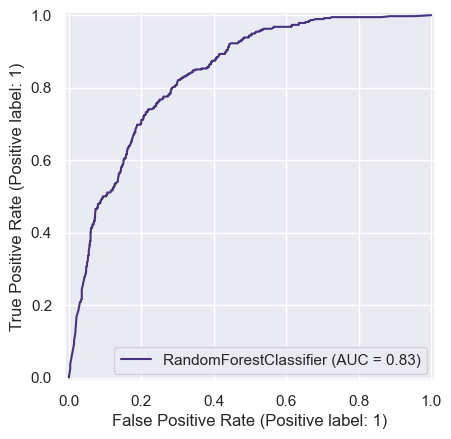

In [228]:
RocCurveDisplay.from_estimator(rf_best, X_test, y_test)
plt.show()

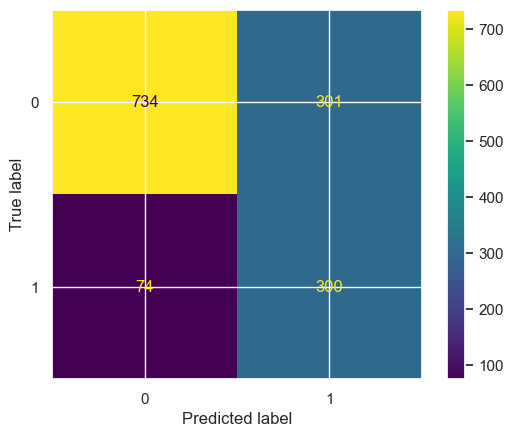

In [ ]:
ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test)
plt.show()

In [232]:
# export best model

joblib.dump(rf_best, "best_model.joblib")

['best_model.joblib']

In [17]:
# export test data
test_data = X_test.copy()
test_data["Churn"] = y_test
test_data.to_csv("data/processed/test_data.csv", index=False)

# TO DO

* Make a data preproc pipeline from the original data
* make a streamlit GUI
* Make it work online